# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]


In [2]:
# For a simple and interpretable baseline, i use Logistic Regression with Bag-of-Words features from the tweet text.

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]


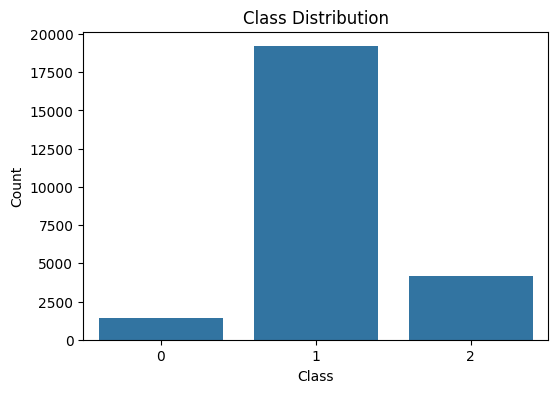

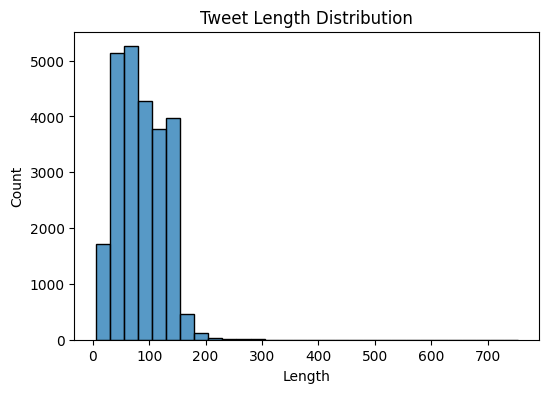

In [3]:
# Load the dataset
df = pd.read_csv('../1_DatasetCharacteristics/labeled_data.csv')

# Show class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Show text length distribution
df['text_length'] = df['tweet'].astype(str).apply(len)
plt.figure(figsize=(6, 4))
sns.histplot(df['text_length'], bins=30)
plt.title('Tweet Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

# Use only the tweet text as feature
X_text = df['tweet'].astype(str)
y = df['class']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

## Implementation

[Implement your baseline model here.]



In [4]:
# Initialize and train the baseline model
# Klassifikationsmodell
vectorizer = CountVectorizer(max_features=5000)
X_train_cv = vectorizer.fit_transform(X_train)
model = LogisticRegression(max_iter=200)
model.fit(X_train_cv, y_train)

LogisticRegression(max_iter=200)

In [5]:
results = []

# 1. DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train.values.reshape(-1, 1), y_train)
y_pred_dummy = dummy.predict(X_test.values.reshape(-1, 1))
results.append({
    'model': 'DummyClassifier',
    'accuracy': accuracy_score(y_test, y_pred_dummy),
    'precision': precision_score(y_test, y_pred_dummy, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_dummy, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0)
})
print("DummyClassifier Results:")
print(classification_report(y_test, y_pred_dummy))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))

DummyClassifier Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       290
           1       0.77      1.00      0.87      3832
           2       0.00      0.00      0.00       835

    accuracy                           0.77      4957
   macro avg       0.26      0.33      0.29      4957
weighted avg       0.60      0.77      0.67      4957

Confusion Matrix:
 [[   0  290    0]
 [   0 3832    0]
 [   0  835    0]]


c:\Users\ayham\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ayham\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ayham\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [6]:
# 2. Logistic Regression (CountVectorizer)
vectorizer = CountVectorizer(max_features=5000)
X_train_cv = vectorizer.fit_transform(X_train)
X_test_cv = vectorizer.transform(X_test)
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_cv, y_train)
y_pred_logreg = logreg.predict(X_test_cv)
results.append({
    'model': 'LogisticRegression (CountVec)',
    'accuracy': accuracy_score(y_test, y_pred_logreg),
    'precision': precision_score(y_test, y_pred_logreg, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_logreg, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_logreg, average='weighted', zero_division=0)
})
print("\nLogistic Regression (CountVectorizer) Results:")
print(classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))


Logistic Regression (CountVectorizer) Results:
              precision    recall  f1-score   support

           0       0.46      0.24      0.32       290
           1       0.93      0.95      0.94      3832
           2       0.84      0.88      0.86       835

    accuracy                           0.90      4957
   macro avg       0.74      0.69      0.71      4957
weighted avg       0.89      0.90      0.89      4957

Confusion Matrix:
 [[  71  187   32]
 [  73 3648  111]
 [   9   95  731]]


In [7]:
# 3. Naive Bayes (CountVectorizer)
nb = MultinomialNB()
nb.fit(X_train_cv, y_train)
y_pred_nb = nb.predict(X_test_cv)
results.append({
    'model': 'NaiveBayes (CountVec)',
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'precision': precision_score(y_test, y_pred_nb, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_nb, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)
})
print("\nNaive Bayes (CountVectorizer) Results:")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


Naive Bayes (CountVectorizer) Results:
              precision    recall  f1-score   support

           0       0.43      0.23      0.30       290
           1       0.91      0.96      0.93      3832
           2       0.82      0.74      0.78       835

    accuracy                           0.88      4957
   macro avg       0.72      0.64      0.67      4957
weighted avg       0.86      0.88      0.87      4957

Confusion Matrix:
 [[  67  184   39]
 [  73 3664   95]
 [  16  197  622]]


In [8]:
# 4. Logistic Regression (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
logreg_tfidf = LogisticRegression(max_iter=200)
logreg_tfidf.fit(X_train_tfidf, y_train)
y_pred_logreg_tfidf = logreg_tfidf.predict(X_test_tfidf)
results.append({
    'model': 'LogisticRegression (TFIDF)',
    'accuracy': accuracy_score(y_test, y_pred_logreg_tfidf),
    'precision': precision_score(y_test, y_pred_logreg_tfidf, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_logreg_tfidf, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_logreg_tfidf, average='weighted', zero_division=0)
})
print("\nLogistic Regression (TF-IDF) Results:")
print(classification_report(y_test, y_pred_logreg_tfidf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg_tfidf))


Logistic Regression (TF-IDF) Results:
              precision    recall  f1-score   support

           0       0.53      0.17      0.26       290
           1       0.91      0.96      0.94      3832
           2       0.84      0.81      0.83       835

    accuracy                           0.89      4957
   macro avg       0.76      0.65      0.67      4957
weighted avg       0.88      0.89      0.88      4957

Confusion Matrix:
 [[  49  210   31]
 [  40 3693   99]
 [   4  151  680]]


## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]




Baseline Model Comparison:
                           model  accuracy  precision    recall        f1
1  LogisticRegression (CountVec)  0.897720   0.885614  0.897720  0.889493
3     LogisticRegression (TFIDF)  0.892072   0.876448  0.892072  0.878268
2          NaiveBayes (CountVec)  0.878152   0.863952  0.878152  0.868456
0                DummyClassifier  0.773048   0.597604  0.773048  0.674097


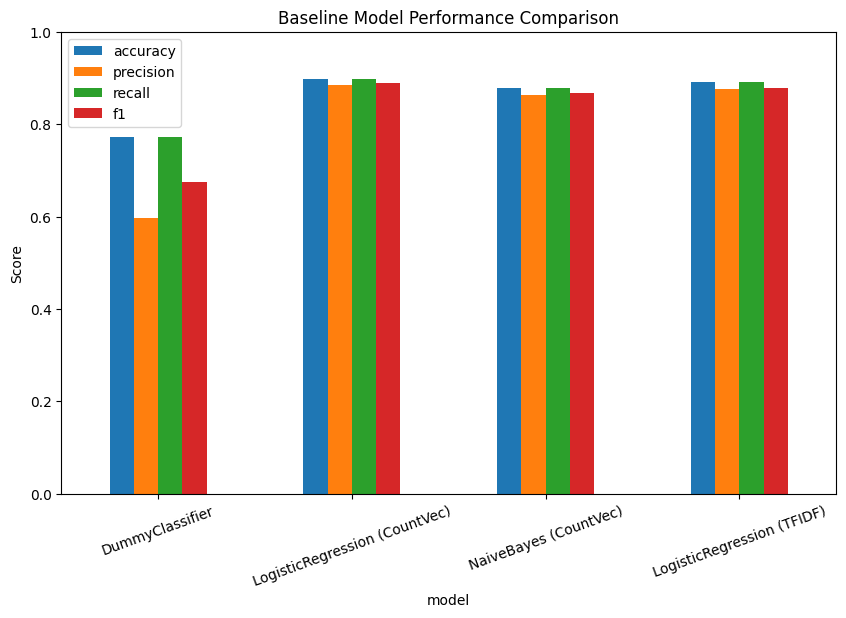

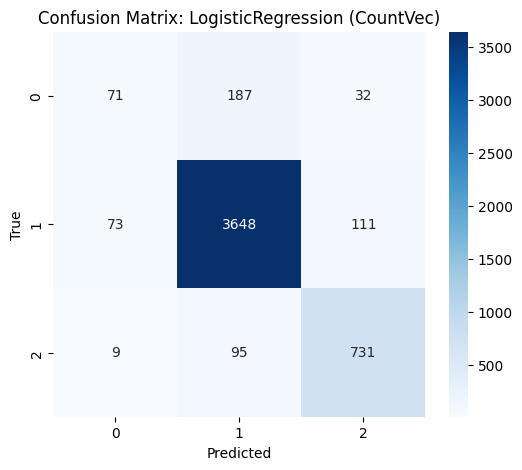

In [9]:
# Evaluate the baseline model
results_df = pd.DataFrame(results)
print("\nBaseline Model Comparison:")
print(results_df.sort_values('accuracy', ascending=False))

# Visualize Best Model Confusion Matrix
best_idx = results_df['accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'model']
if best_model_name == 'LogisticRegression (CountVec)':
    best_pred = y_pred_logreg
elif best_model_name == 'NaiveBayes (CountVec)':
    best_pred = y_pred_nb
elif best_model_name == 'LogisticRegression (TFIDF)':
    best_pred = y_pred_logreg_tfidf
else:
    best_pred = y_pred_dummy

results_df.plot(x='model', y=['accuracy', 'precision', 'recall', 'f1'], kind='bar', figsize=(10,6))
plt.title('Baseline Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.show()

# Save best accuracy for comparison with advanced models
with open("baseline_accuracy.txt", "w") as f:
    f.write(str(results_df.loc[best_idx, 'accuracy']))